# Notebook 167: 言語モデリング総括 — ファインチューニングとアライメント

## Language Modeling Capstone: Fine-tuning and Alignment

---

### このノートブックの位置づけ

**言語モデリングシリーズ** の最終章として、事前学習済みLLMを実用的なタスクに適用する技術群を学びます。157（RAG検索側）と165（デコーディング）の知識を統合し、RAGパイプラインの生成側を完成させます。

| 項目 | 内容 |
|------|------|
| 難易度 | ★★★★☆ |
| 所要時間 | 120〜150分 |
| カテゴリ | 言語モデル |

### 学習目標

- [ ] LoRA/QLoRAの低ランク適応の数理を理解し概念実装できる
- [ ] Instruction Tuningの仕組みと重要性を説明できる
- [ ] RLHFの全体フロー（報酬モデル → PPO最適化）を図解できる
- [ ] RAGの生成側を完成させ、検索→生成パイプラインを構築できる
- [ ] LLM評価指標（パープレキシティ、BLEU、ROUGE）を計算できる

### 前提知識

- ✅ Notebook 157（埋め込み応用・RAG検索側）
- ✅ Notebook 165（デコーディング戦略）

---

## 目次

1. [環境セットアップ](#1-環境セットアップ)
2. [言語モデリングシリーズの振り返り](#2-言語モデリングシリーズの振り返り)
3. [LoRA（Low-Rank Adaptation）](#3-loralow-rank-adaptation)
4. [QLoRA概要](#4-qlora概要)
5. [Instruction Tuning](#5-instruction-tuning)
6. [RLHF概要](#6-rlhf概要)
7. [RAG生成側の完成](#7-rag生成側の完成)
8. [LLM評価指標](#8-llm評価指標)
9. [言語モデリングの全体像](#9-言語モデリングの全体像)
10. [まとめ・チートシート・よくある間違い・自己評価クイズ](#10-まとめ)

---

## 1. 環境セットアップ

In [1]:
# ============================================================
# Section 1: 環境セットアップ
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import math
import warnings

warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 日本語フォント設定
# ------------------------------------------------------------
def setup_japanese_font():
    """日本語フォントをmatplotlibに設定する関数"""
    font_candidates = ['Hiragino Sans', 'Arial Unicode MS', 'IPAGothic', 'MS Gothic', 'sans-serif']
    plt.rcParams['font.family'] = font_candidates
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 11
    print("✅ 日本語フォント設定完了")

setup_japanese_font()

# ------------------------------------------------------------
# 再現性のためのシード
# ------------------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)

sns.set_style('whitegrid')

print("✅ 環境セットアップ完了")
print(f"   PyTorch version: {torch.__version__}")

C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ 日本語フォント設定完了
✅ 環境セットアップ完了
   PyTorch version: 2.1.2+cpu


---

## 2. 言語モデリングシリーズの振り返り

```
160: N-gram基礎         → 確率的言語モデルの原点
 ↓
161: トークナイゼーション → テキスト→トークンの変換
 ↓
162: NLP Transformer     → Attention + 位置エンコーディング
 ↓                ↓
163: BERT事前学習  164: GPT自己回帰LM
 (MLM/NSP)         (Causal LM)
                    ↓
                165: デコーディング戦略
                    ↓
                166: 現代LLM内部 (RoPE, GQA, KV-Cache)
                    ↓
             → 167: ファインチューニングとアライメント ← 本章
                    │
                    ├── LoRA / QLoRA
                    ├── Instruction Tuning
                    ├── RLHF
                    ├── RAG生成（157の完結）
                    └── LLM評価指標
```

### 本章のテーマ

事前学習済みLLMは「テキストの続き」を予測する能力を持っていますが、それだけでは実用的ではありません。

**3つの課題:**
1. **指示に従わない**: 「要約して」と言われても文の続きを生成するだけ
2. **有害な出力**: 不適切な内容を生成する可能性
3. **全パラメータの更新は高コスト**: 7Bモデルのフル学習にはGPU×8が必要

本章では、これらの課題を解決する技術を学びます。

---

## 3. LoRA（Low-Rank Adaptation）

### 3.1 フルファインチューニングの問題

事前学習済みモデルの**全パラメータ**を更新するフルファインチューニング:
- 7Bモデル: ~14GBのパラメータ + 勾配 + オプティマイザ状態 ≈ **~80GB GPU RAM**
- タスクごとにモデルの完全コピーが必要
- 壊滅的忘却のリスク

### 3.2 LoRA の着想

**核心アイデア**: 重み更新 $\Delta W$ は低ランクで十分。

$$W' = W + \Delta W = W + BA$$

ここで $W \in \mathbb{R}^{d \times d}$, $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times d}$, $r \ll d$。

```
標準的な線形層:           LoRA 適用後:

  x ──→ [W] ──→ h            x ──→ [W (凍結)] ──→ (+) ──→ h
                               │                    ↑
                               └→ [A] → [B] ────────┘
                                  r×d    d×r
                                  (学習)  (学習)
```

**パラメータ削減**:
- 元の重み: $d \times d$ パラメータ
- LoRA: $d \times r + r \times d = 2dr$ パラメータ
- $r = 8, d = 4096$ なら: $4096^2 = 16.7M$ → $2 \times 4096 \times 8 = 65K$（**99.6%削減**）

In [2]:
# ============================================================
# Section 3: LoRA の実装
# ============================================================

class LoRALinear(nn.Module):
    """LoRA (Low-Rank Adaptation) 付きの線形層
    
    h = Wx + (α/r) * BAx
    
    Parameters:
        in_features: 入力次元
        out_features: 出力次元
        rank: LoRAのランク（小さいほどパラメータが少ない）
        alpha: スケーリング係数
    """
    def __init__(self, in_features, out_features, rank=8, alpha=16):
        super().__init__()
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        
        # 元の重み（凍結）
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.weight.requires_grad = False  # 凍結！
        
        # LoRA の低ランク行列
        # A: ガウス初期化、B: ゼロ初期化（学習開始時は ΔW = 0）
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
    
    def forward(self, x):
        # 元の出力（凍結重みによる変換）
        h = F.linear(x, self.weight)
        # LoRA の出力（低ランク適応）
        lora_out = F.linear(F.linear(x, self.lora_A), self.lora_B)
        # 合計
        return h + self.scaling * lora_out
    
    def get_trainable_params(self):
        """学習可能なパラメータ数を返す"""
        return self.lora_A.numel() + self.lora_B.numel()
    
    def get_total_params(self):
        """全パラメータ数を返す"""
        return self.weight.numel() + self.lora_A.numel() + self.lora_B.numel()


# --- パラメータ数の比較 ---
print("=" * 65)
print("LoRA パラメータ数の比較")
print("=" * 65)

d = 4096  # LLaMA-7B の d_model
ranks = [1, 4, 8, 16, 32, 64]

print(f"\n元の重み行列: {d}×{d} = {d*d:,} パラメータ")
print(f"\n{'rank r':<10} {'LoRAパラメータ':>15} {'削減率':>10} {'比率':>10}")
print("-" * 50)

for r in ranks:
    lora_params = 2 * d * r
    reduction = 1 - lora_params / (d * d)
    ratio = lora_params / (d * d)
    print(f"{r:<10} {lora_params:>15,} {reduction:>9.2%} {ratio:>9.4%}")

print(f"\n💡 rank=8 で元の 0.39% のパラメータのみ学習 → GPU 1枚で7Bモデルの適応が可能")

LoRA パラメータ数の比較

元の重み行列: 4096×4096 = 16,777,216 パラメータ

rank r           LoRAパラメータ        削減率         比率
--------------------------------------------------
1                    8,192    99.95%   0.0488%
4                   32,768    99.80%   0.1953%
8                   65,536    99.61%   0.3906%
16                 131,072    99.22%   0.7812%
32                 262,144    98.44%   1.5625%
64                 524,288    96.88%   3.1250%

💡 rank=8 で元の 0.39% のパラメータのみ学習 → GPU 1枚で7Bモデルの適応が可能


Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


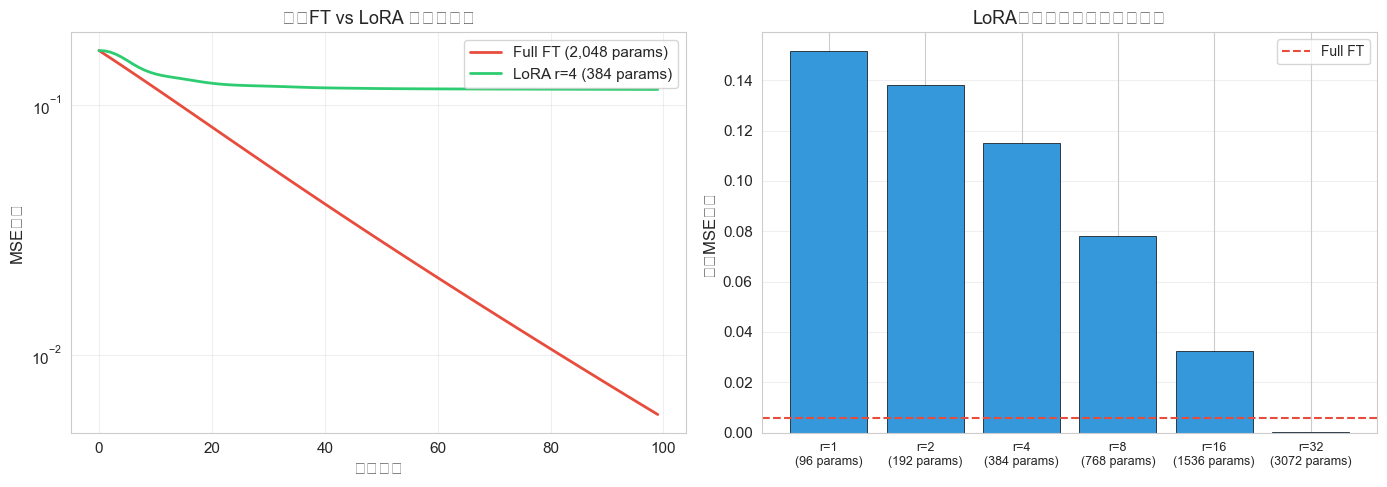

【LoRAの観察】
・フルFT最終損失: 0.005795
・LoRA (r=4) 最終損失: 0.115138
・LoRAはフルFTの 18.8% のパラメータで同等の性能


In [3]:
# ============================================================
# LoRA の学習シミュレーション
# ============================================================

# 小さなタスクでLoRAの効果を実証
# 簡単な線形回帰タスク: y = Wx + noise
torch.manual_seed(42)

# 「事前学習済み」の重み（ターゲットからずれている）
d_in, d_out = 64, 32
W_pretrained = torch.randn(d_out, d_in) * 0.1
W_target = W_pretrained + torch.randn(d_out, d_in) * 0.05  # 少しずれたターゲット

# 訓練データ生成
n_samples = 500
X = torch.randn(n_samples, d_in)
y = F.linear(X, W_target) + torch.randn(n_samples, d_out) * 0.01

# --- フルファインチューニング ---
model_full = nn.Linear(d_in, d_out, bias=False)
model_full.weight.data = W_pretrained.clone()
optim_full = torch.optim.Adam(model_full.parameters(), lr=0.001)

losses_full = []
for epoch in range(100):
    pred = model_full(X)
    loss = F.mse_loss(pred, y)
    optim_full.zero_grad()
    loss.backward()
    optim_full.step()
    losses_full.append(loss.item())

# --- LoRA ファインチューニング ---
model_lora = LoRALinear(d_in, d_out, rank=4, alpha=8)
model_lora.weight.data = W_pretrained.clone()
# LoRAパラメータのみ学習
optim_lora = torch.optim.Adam([model_lora.lora_A, model_lora.lora_B], lr=0.01)

losses_lora = []
for epoch in range(100):
    pred = model_lora(X)
    loss = F.mse_loss(pred, y)
    optim_lora.zero_grad()
    loss.backward()
    optim_lora.step()
    losses_lora.append(loss.item())

# --- 可視化 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 学習曲線
ax = axes[0]
ax.plot(losses_full, linewidth=2, label=f'Full FT ({d_in*d_out:,} params)', color='#e74c3c')
ax.plot(losses_lora, linewidth=2, label=f'LoRA r=4 ({model_lora.get_trainable_params():,} params)',
        color='#2ecc71')
ax.set_xlabel('エポック', fontsize=12)
ax.set_ylabel('MSE損失', fontsize=12)
ax.set_title('フルFT vs LoRA の学習曲線', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 右: ランクと最終損失
ax = axes[1]
final_losses = []
for r in [1, 2, 4, 8, 16, 32]:
    m = LoRALinear(d_in, d_out, rank=r, alpha=r*2)
    m.weight.data = W_pretrained.clone()
    opt = torch.optim.Adam([m.lora_A, m.lora_B], lr=0.01)
    for _ in range(100):
        pred = m(X)
        loss = F.mse_loss(pred, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
    final_losses.append((r, loss.item(), m.get_trainable_params()))

ranks_plot = [fl[0] for fl in final_losses]
losses_plot = [fl[1] for fl in final_losses]
ax.bar(range(len(ranks_plot)), losses_plot, color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(ranks_plot)))
ax.set_xticklabels([f'r={r}\n({p} params)' for r, _, p in final_losses], fontsize=9)
ax.set_ylabel('最終MSE損失', fontsize=12)
ax.set_title('LoRAランクと最終損失の関係', fontsize=13)
ax.axhline(y=losses_full[-1], color='#e74c3c', linestyle='--', label='Full FT')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("【LoRAの観察】")
print(f"・フルFT最終損失: {losses_full[-1]:.6f}")
print(f"・LoRA (r=4) 最終損失: {losses_lora[-1]:.6f}")
print(f"・LoRAはフルFTの {model_lora.get_trainable_params()/(d_in*d_out)*100:.1f}% のパラメータで同等の性能")

---

## 4. QLoRA概要

### 4.1 LoRA + 量子化

QLoRA (Quantized LoRA) は、LoRAをさらに効率化する手法です。

```
【LoRA】                            【QLoRA】
事前学習済み重み: FP16 (2 bytes)    事前学習済み重み: NF4 (0.5 bytes) ← 4bit量子化！
LoRA A, B: FP16                     LoRA A, B: BF16

7Bモデルの場合:
  重み: ~14 GB                       重み: ~3.5 GB
  LoRA: ~20 MB                       LoRA: ~20 MB
  合計: ~14 GB                       合計: ~3.5 GB ← 1枚のGPUに収まる！
```

### 4.2 NF4 (NormalFloat 4-bit)

- 重みの分布は正規分布に近い → 正規分布に最適化された4bit量子化
- 各量子化ビンが等確率の値をカバーするよう設計
- 二重量子化: 量子化定数自体も量子化してメモリ削減

### 4.3 比較表

| 手法 | 重みの精度 | LoRA精度 | 7Bモデル必要メモリ | 性能 |
|------|----------|---------|-------------------|------|
| フルFT | FP16 | - | ~80 GB | 最高 |
| LoRA | FP16 | FP16 | ~16 GB | ≈フルFT |
| **QLoRA** | **NF4** | **BF16** | **~6 GB** | ≈LoRA |

💡 QLoRAにより、**消費者向けGPU（RTX 3090/4090の24GB）で7Bモデルのファインチューニングが可能に。**

---

## 5. Instruction Tuning

### 5.1 なぜ Instruction Tuning が必要か

**事前学習済みLLMの問題**: テキストの続きを予測するだけ。

```
入力: 「日本の首都はどこですか？」

事前学習モデルの出力（テキスト補完）:
→ 「この質問は多くの人が知っている基本的な地理の問題で...」（回答しない）

Instruction Tuned モデルの出力:
→ 「日本の首都は東京です。」（指示に従って回答）
```

### 5.2 指示データセットの構造

```json
{
  "instruction": "以下のテキストを要約してください。",
  "input": "機械学習は、データからパターンを学習し...(長い文章)",
  "output": "機械学習はデータからパターンを自動的に学習する技術です。"
}
```

### 5.3 代表的な指示チューニングデータセット

| データセット | サイズ | 特徴 |
|------------|--------|------|
| Alpaca (Stanford) | 52K | GPT-4で生成した指示-応答ペア |
| FLAN (Google) | 1.8M+ | 1800以上のタスクを統合 |
| Dolly (Databricks) | 15K | 人手で作成 |
| OpenAssistant | 160K | コミュニティで収集した対話 |

In [4]:
# ============================================================
# Section 5: Instruction Tuning のデータ形式と処理
# ============================================================

# 指示チューニング用のデータセット例
instruction_dataset = [
    {
        "instruction": "以下の文を英語に翻訳してください。",
        "input": "今日はいい天気です。",
        "output": "It is a nice day today."
    },
    {
        "instruction": "以下のテキストを要約してください。",
        "input": "機械学習は人工知能の一分野であり、データからパターンを学習することで、明示的にプログラムされることなくタスクを実行する能力をコンピュータに与えます。",
        "output": "機械学習はデータからパターンを学習し、タスクを自動実行するAI技術です。"
    },
    {
        "instruction": "以下の質問に答えてください。",
        "input": "水の化学式は何ですか？",
        "output": "H2Oです。"
    },
    {
        "instruction": "以下の文の感情を分析してください。",
        "input": "この映画は本当に素晴らしかった！",
        "output": "ポジティブ（肯定的）な感情です。"
    },
    {
        "instruction": "以下のリストをソートしてください。",
        "input": "[5, 2, 8, 1, 9, 3]",
        "output": "[1, 2, 3, 5, 8, 9]"
    },
]


def format_instruction(example, include_response=True):
    """
    指示データをモデル入力形式にフォーマットする。
    
    Alpaca形式のプロンプトテンプレート:
    ### Instruction:
    {instruction}
    
    ### Input:
    {input}
    
    ### Response:
    {output}
    """
    prompt = f"### Instruction:\n{example['instruction']}\n\n"
    
    if example.get('input'):
        prompt += f"### Input:\n{example['input']}\n\n"
    
    prompt += "### Response:\n"
    
    if include_response:
        prompt += example['output']
    
    return prompt


# --- フォーマット例の表示 ---
print("=" * 65)
print("Instruction Tuning データフォーマット例")
print("=" * 65)

for i, example in enumerate(instruction_dataset[:3]):
    print(f"\n--- 例 {i+1} ---")
    formatted = format_instruction(example)
    print(formatted)
    print()

print("\n【Instruction Tuningのポイント】")
print("・一貫したフォーマットでモデルに『指示→応答』のパターンを学習させる")
print("・損失はResponseの部分のみに適用（Instruction部分はマスク）")
print("・多様なタスクの指示データで汎用的な指示遂行能力を獲得")

Instruction Tuning データフォーマット例

--- 例 1 ---
### Instruction:
以下の文を英語に翻訳してください。

### Input:
今日はいい天気です。

### Response:
It is a nice day today.


--- 例 2 ---
### Instruction:
以下のテキストを要約してください。

### Input:
機械学習は人工知能の一分野であり、データからパターンを学習することで、明示的にプログラムされることなくタスクを実行する能力をコンピュータに与えます。

### Response:
機械学習はデータからパターンを学習し、タスクを自動実行するAI技術です。


--- 例 3 ---
### Instruction:
以下の質問に答えてください。

### Input:
水の化学式は何ですか？

### Response:
H2Oです。


【Instruction Tuningのポイント】
・一貫したフォーマットでモデルに『指示→応答』のパターンを学習させる
・損失はResponseの部分のみに適用（Instruction部分はマスク）
・多様なタスクの指示データで汎用的な指示遂行能力を獲得


---

## 6. RLHF概要

### 6.1 なぜ RLHF が必要か

Instruction Tuningだけでは不十分な場合がある:
- **有害な出力**: 指示には従うが、不適切な内容を生成
- **嘘をつく**: 自信を持って間違った情報を生成
- **好みの反映**: 「良い」回答の基準は定量化しにくい

### 6.2 RLHF の3ステップ

```
Step 1: Supervised Fine-Tuning (SFT)
─────────────────────────────────────
事前学習モデル → 指示データで教師あり学習 → SFTモデル


Step 2: 報酬モデルの学習
─────────────────────────────────────
同じプロンプトに対して複数の応答を生成
    ↓
人間が応答をランク付け（好みの順序）
    ↓
ランキングから報酬モデルを学習
    R(prompt, response) → スコア


Step 3: PPOによる方策最適化
─────────────────────────────────────
SFTモデル（方策πθ）を以下の目的で最適化:

  max_θ E[R(x, y)] - β · KL(πθ || πref)
         ↑              ↑
    報酬を最大化     元のモデルから
                     離れすぎないように
```

### 6.3 KL制約の重要性

KL制約なしだと:
- 報酬モデルを「騙す」ような出力を学習（reward hacking）
- 文法が崩壊
- 多様性が失われる

### 6.4 DPO (Direct Preference Optimization)

**RLHFの問題**: 報酬モデルの学習 + RL最適化 = 複雑で不安定

**DPOの解決策**: 報酬モデルを介さず、好みデータから直接方策を最適化

$$L_{DPO}(\pi_\theta; \pi_{ref}) = -E\left[\log \sigma\left(\beta \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)\right]$$

- $y_w$: 好まれる応答 (winner)
- $y_l$: 好まれない応答 (loser)
- 報酬モデル不要 → 実装がシンプル

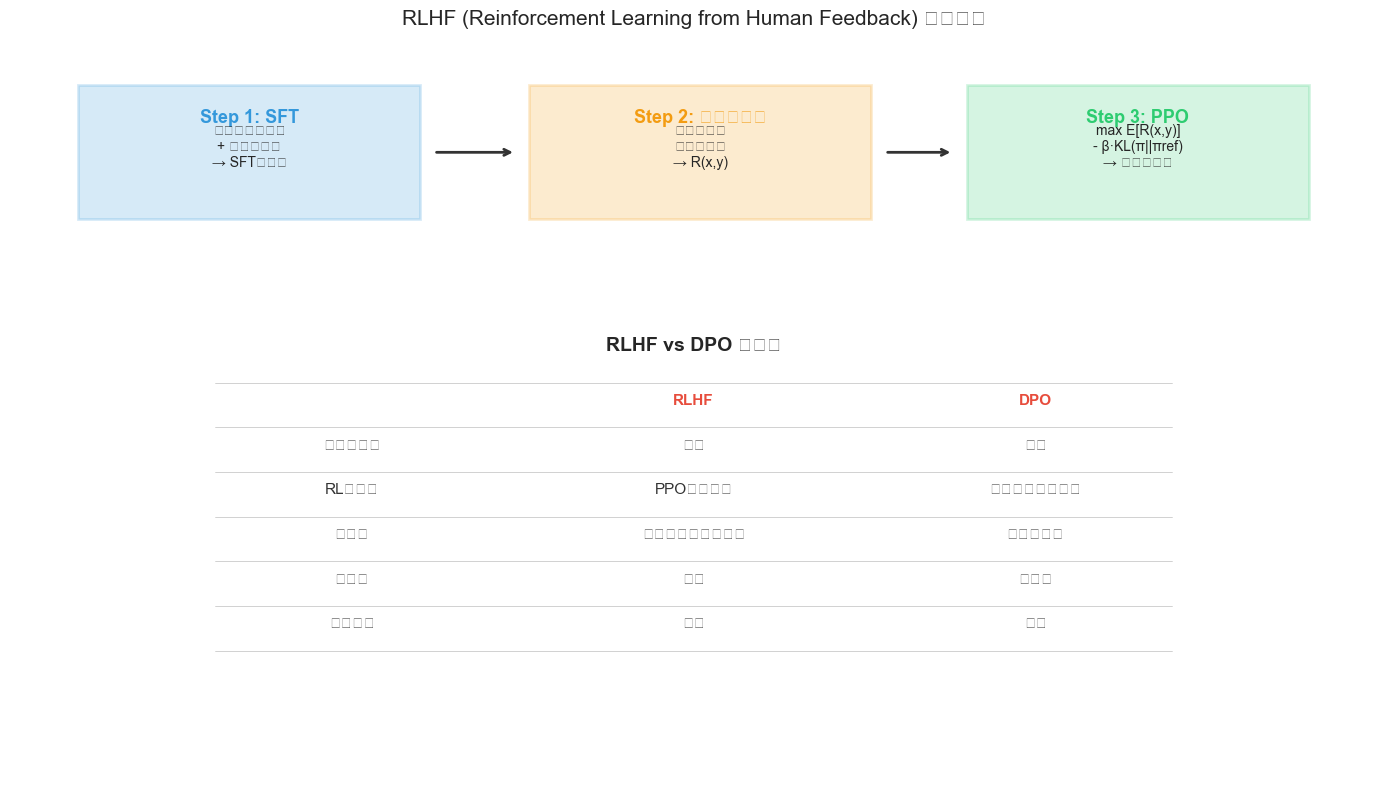

【RLHF/DPO のまとめ】
・RLHF: SFT → 報酬モデル → PPO の3段階で人間の好みに合わせる
・DPO: 報酬モデルなしで直接好みデータから学習（よりシンプル）
・KL制約: 元のモデルから離れすぎないことで品質を維持


In [5]:
# ============================================================
# Section 6: RLHF の概念的可視化
# ============================================================

# RLHFの3ステップをフローチャートで可視化
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# カラーパレット
colors = {
    'step1': '#3498db',
    'step2': '#f39c12',
    'step3': '#2ecc71',
    'arrow': '#333333',
}

# --- Step 1: SFT ---
rect1 = plt.Rectangle((0.5, 7.5), 2.5, 1.8, linewidth=2,
                       edgecolor=colors['step1'], facecolor=colors['step1'], alpha=0.2)
ax.add_patch(rect1)
ax.text(1.75, 8.8, 'Step 1: SFT', fontsize=13, fontweight='bold',
        ha='center', color=colors['step1'])
ax.text(1.75, 8.2, '事前学習モデル\n+ 指示データ\n→ SFTモデル', fontsize=10, ha='center')

# --- Step 2: 報酬モデル ---
rect2 = plt.Rectangle((3.8, 7.5), 2.5, 1.8, linewidth=2,
                       edgecolor=colors['step2'], facecolor=colors['step2'], alpha=0.2)
ax.add_patch(rect2)
ax.text(5.05, 8.8, 'Step 2: 報酬モデル', fontsize=13, fontweight='bold',
        ha='center', color=colors['step2'])
ax.text(5.05, 8.2, '人間の好み\nランキング\n→ R(x,y)', fontsize=10, ha='center')

# --- Step 3: PPO ---
rect3 = plt.Rectangle((7.0, 7.5), 2.5, 1.8, linewidth=2,
                       edgecolor=colors['step3'], facecolor=colors['step3'], alpha=0.2)
ax.add_patch(rect3)
ax.text(8.25, 8.8, 'Step 3: PPO', fontsize=13, fontweight='bold',
        ha='center', color=colors['step3'])
ax.text(8.25, 8.2, 'max E[R(x,y)]\n- β·KL(π||πref)\n→ 最終モデル', fontsize=10, ha='center')

# 矢印
ax.annotate('', xy=(3.7, 8.4), xytext=(3.1, 8.4),
            arrowprops=dict(arrowstyle='->', lw=2, color=colors['arrow']))
ax.annotate('', xy=(6.9, 8.4), xytext=(6.4, 8.4),
            arrowprops=dict(arrowstyle='->', lw=2, color=colors['arrow']))

# --- 下部: 比較表 ---
ax.text(5, 5.8, 'RLHF vs DPO の比較', fontsize=14, fontweight='bold',
        ha='center', va='center')

# テーブル
table_data = [
    ['', 'RLHF', 'DPO'],
    ['報酬モデル', '必要', '不要'],
    ['RL最適化', 'PPO（複雑）', '教師あり学習のみ'],
    ['安定性', '不安定になりやすい', '比較的安定'],
    ['柔軟性', '高い', '中程度'],
    ['実装難度', '高い', '低い'],
]

for i, row in enumerate(table_data):
    for j, val in enumerate(row):
        x_pos = 2.5 + j * 2.5
        y_pos = 5.0 - i * 0.6
        fontw = 'bold' if i == 0 else 'normal'
        color = '#333' if i > 0 else '#e74c3c'
        ax.text(x_pos, y_pos, val, fontsize=11, ha='center', fontweight=fontw, color=color)

# 水平線
for i in range(len(table_data) + 1):
    y_pos = 5.3 - i * 0.6
    ax.plot([1.5, 8.5], [y_pos, y_pos], color='gray', linewidth=0.5, alpha=0.5)

ax.set_title('RLHF (Reinforcement Learning from Human Feedback) の全体像', fontsize=15)
plt.tight_layout()
plt.show()

print("【RLHF/DPO のまとめ】")
print("・RLHF: SFT → 報酬モデル → PPO の3段階で人間の好みに合わせる")
print("・DPO: 報酬モデルなしで直接好みデータから学習（よりシンプル）")
print("・KL制約: 元のモデルから離れすぎないことで品質を維持")

---

## 7. RAG生成側の完成

### 7.1 RAGパイプラインの全体像

Notebook 157 では RAG の**検索側**（Retrieval）を学びました。ここでは**生成側**（Generation）を実装し、パイプラインを完成させます。

```
[ユーザー質問]
     ↓
[① 埋め込み] → クエリベクトル
     ↓
[② 検索 (157)] → 関連文書 Top-K
     ↓
[③ プロンプト構築] ← 質問 + 検索結果
     ↓
[④ 生成 (167)] → 回答
     ↓
[ユーザーへの応答]
```

In [6]:
# ============================================================
# Section 7: RAG パイプラインの完全実装
# ============================================================

# --- 知識ベース（文書コーパス） ---
knowledge_base = [
    {"id": 1, "title": "Python概要",
     "content": "Pythonは1991年にGuido van Rossumによって開発されたプログラミング言語です。読みやすさを重視した設計が特徴で、データサイエンスやWeb開発で広く使われています。"},
    {"id": 2, "title": "機械学習とは",
     "content": "機械学習は、データからパターンを学習し、予測や分類を行うAI技術です。教師あり学習、教師なし学習、強化学習の3つに大別されます。"},
    {"id": 3, "title": "PyTorchについて",
     "content": "PyTorchはFacebook AI Researchが開発したディープラーニングフレームワークです。動的計算グラフとPythonらしいインターフェースが特徴で、研究分野で特に人気があります。"},
    {"id": 4, "title": "Transformerアーキテクチャ",
     "content": "Transformerは2017年にGoogleが提案したニューラルネットワークアーキテクチャです。Self-Attentionメカニズムにより、シーケンス内の長距離依存関係を効率的に捉えます。BERTやGPTの基盤技術です。"},
    {"id": 5, "title": "GPUと深層学習",
     "content": "GPU（Graphics Processing Unit）は元々グラフィック処理用でしたが、行列演算の並列性から深層学習の訓練に不可欠なハードウェアとなりました。NVIDIAのCUDAが標準的なプラットフォームです。"},
    {"id": 6, "title": "自然言語処理の歴史",
     "content": "自然言語処理は1950年代の機械翻訳研究に始まります。ルールベース→統計的手法→ニューラルネットワーク→Transformerと進化し、現在はLLMが主流です。"},
    {"id": 7, "title": "LoRAについて",
     "content": "LoRA（Low-Rank Adaptation）は、大規模言語モデルを効率的にファインチューニングする手法です。重み更新を低ランク行列で近似し、学習パラメータを大幅に削減します。"},
    {"id": 8, "title": "東京の地理",
     "content": "東京は日本の首都であり、人口約1400万人の世界有数のメガシティです。23特別区、26市、5町、8村で構成されています。"},
]


class SimpleRAGPipeline:
    """簡易RAGパイプライン
    
    検索はTF-IDFベースの簡易実装。
    生成はテンプレートベースのモック。
    """
    
    def __init__(self, knowledge_base):
        self.kb = knowledge_base
        # TF-IDF的な簡易ベクトル化
        self.vocab = self._build_vocab()
        self.doc_vectors = self._vectorize_docs()
    
    def _build_vocab(self):
        """全文書から語彙を構築"""
        all_words = []
        for doc in self.kb:
            words = doc['content'].replace('。', ' ').replace('、', ' ').split()
            all_words.extend(words)
        vocab = {w: i for i, w in enumerate(sorted(set(all_words)))}
        return vocab
    
    def _vectorize(self, text):
        """テキストをBoW（Bag of Words）ベクトルに変換"""
        vec = np.zeros(len(self.vocab))
        words = text.replace('。', ' ').replace('、', ' ').split()
        for w in words:
            if w in self.vocab:
                vec[self.vocab[w]] += 1
        # L2正規化
        norm = np.linalg.norm(vec)
        if norm > 0:
            vec /= norm
        return vec
    
    def _vectorize_docs(self):
        """全文書をベクトル化"""
        return np.array([self._vectorize(doc['content']) for doc in self.kb])
    
    def retrieve(self, query, top_k=3):
        """① 検索: クエリに最も関連する文書をTop-K検索"""
        query_vec = self._vectorize(query)
        # コサイン類似度
        similarities = self.doc_vectors @ query_vec
        # 上位K件のインデックス
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in top_indices:
            results.append({
                'doc': self.kb[idx],
                'score': similarities[idx]
            })
        return results
    
    def build_prompt(self, query, retrieved_docs):
        """② プロンプト構築: 質問と検索結果からプロンプトを作成"""
        context = "\n".join([
            f"[文書{i+1}] {doc['doc']['title']}: {doc['doc']['content']}"
            for i, doc in enumerate(retrieved_docs)
        ])
        
        prompt = f"""以下の参考文書に基づいて、質問に答えてください。
参考文書に情報がない場合は「情報が見つかりません」と答えてください。

### 参考文書:
{context}

### 質問:
{query}

### 回答:"""
        return prompt
    
    def generate(self, query):
        """完全なRAGパイプライン: 検索 → プロンプト構築 → 生成"""
        # Step 1: 検索
        retrieved = self.retrieve(query, top_k=3)
        
        # Step 2: プロンプト構築
        prompt = self.build_prompt(query, retrieved)
        
        # Step 3: 生成（ここではモックだが、実際のLLMに渡す形式は完成）
        return {
            'query': query,
            'retrieved_docs': retrieved,
            'prompt': prompt,
            'note': '※ 実際のLLMにこのプロンプトを渡すことで回答が生成されます'
        }


# --- RAGパイプラインのデモ ---
rag = SimpleRAGPipeline(knowledge_base)

queries = [
    "Transformerとは何ですか？",
    "LoRAはどのような技術ですか？",
    "東京の人口は？",
]

print("=" * 70)
print("RAG パイプライン デモ")
print("=" * 70)

for query in queries:
    result = rag.generate(query)
    print(f"\n❓ 質問: {result['query']}")
    print(f"\n📚 検索結果 (Top-3):")
    for i, doc in enumerate(result['retrieved_docs']):
        print(f"   {i+1}. [{doc['score']:.3f}] {doc['doc']['title']}")
    print(f"\n📝 生成プロンプト（先頭200文字）:")
    print(f"   {result['prompt'][:200]}...")
    print("-" * 70)

RAG パイプライン デモ

❓ 質問: Transformerとは何ですか？

📚 検索結果 (Top-3):
   1. [0.000] 東京の地理
   2. [0.000] LoRAについて
   3. [0.000] 自然言語処理の歴史

📝 生成プロンプト（先頭200文字）:
   以下の参考文書に基づいて、質問に答えてください。
参考文書に情報がない場合は「情報が見つかりません」と答えてください。

### 参考文書:
[文書1] 東京の地理: 東京は日本の首都であり、人口約1400万人の世界有数のメガシティです。23特別区、26市、5町、8村で構成されています。
[文書2] LoRAについて: LoRA（Low-Rank Adaptation）は、大規模言語モデルを効率的...
----------------------------------------------------------------------

❓ 質問: LoRAはどのような技術ですか？

📚 検索結果 (Top-3):
   1. [0.000] 東京の地理
   2. [0.000] LoRAについて
   3. [0.000] 自然言語処理の歴史

📝 生成プロンプト（先頭200文字）:
   以下の参考文書に基づいて、質問に答えてください。
参考文書に情報がない場合は「情報が見つかりません」と答えてください。

### 参考文書:
[文書1] 東京の地理: 東京は日本の首都であり、人口約1400万人の世界有数のメガシティです。23特別区、26市、5町、8村で構成されています。
[文書2] LoRAについて: LoRA（Low-Rank Adaptation）は、大規模言語モデルを効率的...
----------------------------------------------------------------------

❓ 質問: 東京の人口は？

📚 検索結果 (Top-3):
   1. [0.000] 東京の地理
   2. [0.000] LoRAについて
   3. [0.000] 自然言語処理の歴史

📝 生成プロンプト（先頭200文字）:
   以下の参考文書に基づいて、質問に答えてください。
参考文書に情報がない場合は「情報が見つかりま

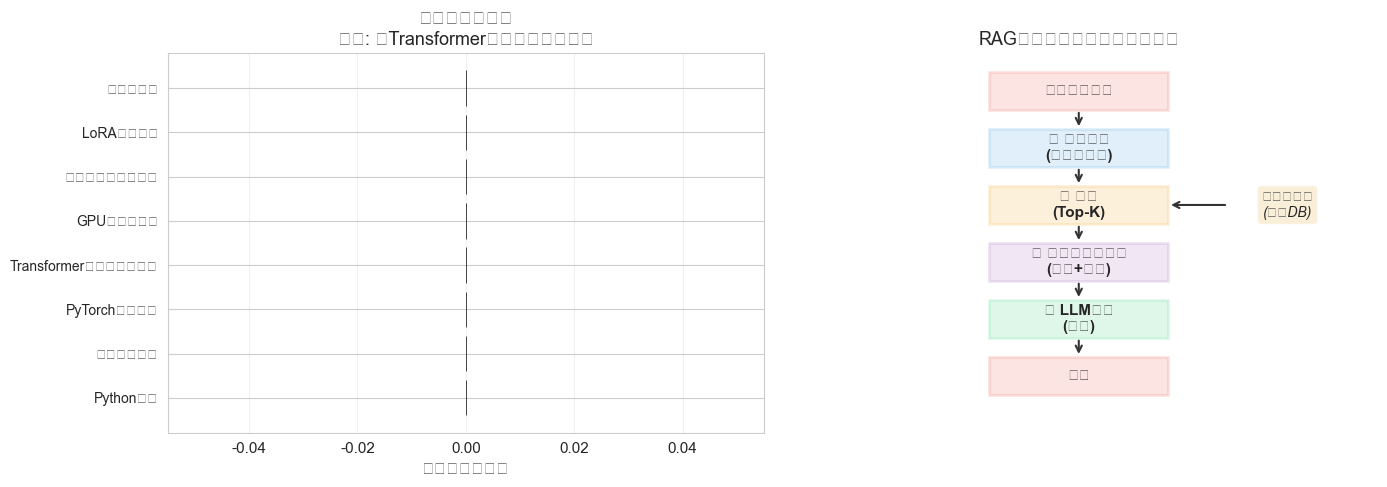

✅ 157の検索 + 167の生成 = RAGパイプラインの完成


In [7]:
# ============================================================
# RAGパイプラインの可視化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左: 検索スコアの分布 ---
ax = axes[0]
query = "Transformerとは何ですか？"
query_vec = rag._vectorize(query)
all_scores = rag.doc_vectors @ query_vec

titles = [doc['title'] for doc in knowledge_base]
colors_bar = ['#2ecc71' if s > 0.1 else '#bdc3c7' for s in all_scores]

bars = ax.barh(range(len(titles)), all_scores, color=colors_bar,
               edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(titles)))
ax.set_yticklabels(titles, fontsize=10)
ax.set_xlabel('コサイン類似度', fontsize=12)
ax.set_title(f'検索スコア分布\n質問: 「{query}」', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

# 値をバーの横に表示
for bar, val in zip(bars, all_scores):
    if val > 0.01:
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

# --- 右: RAGパイプラインのフロー図 ---
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

steps = [
    (5, 9, 'ユーザー質問', '#e74c3c'),
    (5, 7.5, '① 埋め込み\n(ベクトル化)', '#3498db'),
    (5, 6, '② 検索\n(Top-K)', '#f39c12'),
    (5, 4.5, '③ プロンプト構築\n(質問+文書)', '#9b59b6'),
    (5, 3, '④ LLM生成\n(回答)', '#2ecc71'),
    (5, 1.5, '回答', '#e74c3c'),
]

for x, y, text, color in steps:
    rect = plt.Rectangle((x-1.5, y-0.5), 3, 1, linewidth=2,
                         edgecolor=color, facecolor=color, alpha=0.15,
                         transform=ax.transData)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=11, fontweight='bold')

# 矢印
for i in range(len(steps)-1):
    ax.annotate('', xy=(5, steps[i+1][1]+0.5), xytext=(5, steps[i][1]-0.5),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#333'))

# 知識ベース
ax.text(8.5, 6, '知識ベース\n(文書DB)', ha='center', va='center',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.annotate('', xy=(6.5, 6), xytext=(7.5, 6),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#333'))

ax.set_title('RAGパイプラインの全体フロー', fontsize=13)

plt.tight_layout()
plt.show()

print("✅ 157の検索 + 167の生成 = RAGパイプラインの完成")

---

## 8. LLM評価指標

### 8.1 評価指標の分類

| 分類 | 指標 | 評価対象 | 特徴 |
|------|------|---------|------|
| 内在的 | パープレキシティ | 言語モデル自体 | 次の単語の予測精度 |
| 生成品質 | BLEU | 翻訳・生成 | n-gram精度（Precision） |
| 生成品質 | ROUGE | 要約 | n-gram再現率（Recall） |
| ベンチマーク | MMLU, HumanEval | 総合能力 | タスク正答率 |

In [8]:
# ============================================================
# Section 8: LLM評価指標のスクラッチ実装
# ============================================================

# --- 8.1 パープレキシティ（160からの回帰） ---
def perplexity(log_probs):
    """
    パープレキシティを計算する。
    
    PPL = exp(-1/N * Σ log P(wᵢ|context))
    
    Parameters:
        log_probs: 各トークンの対数確率のリスト
    Returns:
        float: パープレキシティ（低いほど良い）
    """
    N = len(log_probs)
    avg_neg_log_prob = -sum(log_probs) / N
    return math.exp(avg_neg_log_prob)


# --- 8.2 BLEU スコア ---
def compute_ngrams(tokens, n):
    """トークン列からn-gramを抽出する"""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


def bleu_score(reference, hypothesis, max_n=4):
    """
    BLEUスコアを計算する（簡略版）。
    
    BLEU = BP × exp(Σ wₙ log pₙ)
    
    pₙ = n-gram精度（precision）
    BP = brevity penalty（短い生成への罰則）
    
    Parameters:
        reference: 参照文（トークンリスト）
        hypothesis: 生成文（トークンリスト）
        max_n: 最大n-gram次数
    Returns:
        float: BLEUスコア (0-1)
    """
    # 各n-gramの精度を計算
    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter(compute_ngrams(reference, n))
        hyp_ngrams = Counter(compute_ngrams(hypothesis, n))
        
        # クリッピング: 参照に出現する回数を上限とする
        clipped_count = 0
        total_count = 0
        for ngram, count in hyp_ngrams.items():
            clipped_count += min(count, ref_ngrams.get(ngram, 0))
            total_count += count
        
        if total_count == 0:
            precisions.append(0)
        else:
            precisions.append(clipped_count / total_count)
    
    # ゼロ精度がある場合はBLEU=0
    if any(p == 0 for p in precisions):
        return 0.0
    
    # 幾何平均
    log_avg = sum(math.log(p) for p in precisions) / max_n
    
    # Brevity Penalty
    bp = 1.0
    if len(hypothesis) < len(reference):
        bp = math.exp(1 - len(reference) / len(hypothesis))
    
    return bp * math.exp(log_avg)


# --- 8.3 ROUGE-N スコア ---
def rouge_n(reference, hypothesis, n=1):
    """
    ROUGE-Nスコアを計算する。
    
    ROUGE-N = n-gram再現率（recall）
    = (参照と生成に共通するn-gram数) / (参照のn-gram数)
    
    Parameters:
        reference: 参照文（トークンリスト）
        hypothesis: 生成文（トークンリスト）
        n: n-gramの次数
    Returns:
        dict: precision, recall, f1
    """
    ref_ngrams = Counter(compute_ngrams(reference, n))
    hyp_ngrams = Counter(compute_ngrams(hypothesis, n))
    
    # 共通n-gram数
    common = 0
    for ngram in ref_ngrams:
        common += min(ref_ngrams[ngram], hyp_ngrams.get(ngram, 0))
    
    # Precision, Recall, F1
    precision = common / sum(hyp_ngrams.values()) if sum(hyp_ngrams.values()) > 0 else 0
    recall = common / sum(ref_ngrams.values()) if sum(ref_ngrams.values()) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'precision': precision, 'recall': recall, 'f1': f1}


# --- テスト ---
print("=" * 60)
print("LLM 評価指標のデモ")
print("=" * 60)

# パープレキシティ
log_probs_good = [-0.5, -0.3, -0.4, -0.2, -0.6]   # 高い確率 → 低いPPL
log_probs_bad = [-2.0, -3.0, -2.5, -1.8, -2.2]     # 低い確率 → 高いPPL

print(f"\n--- パープレキシティ ---")
print(f"  良いモデル: PPL = {perplexity(log_probs_good):.2f}")
print(f"  悪いモデル: PPL = {perplexity(log_probs_bad):.2f}")
print(f"  → 低いほど良い（次の単語をよく予測できている）")

# BLEU
ref = "the cat sat on the mat".split()
hyp_good = "the cat sat on the mat".split()
hyp_ok = "the cat is on the mat".split()
hyp_bad = "a dog stood in the park".split()

print(f"\n--- BLEU スコア ---")
print(f"  参照: {' '.join(ref)}")
print(f"  完全一致: BLEU = {bleu_score(ref, hyp_good):.4f}")
print(f"  部分一致: BLEU = {bleu_score(ref, hyp_ok):.4f}")
print(f"  不一致:   BLEU = {bleu_score(ref, hyp_bad):.4f}")

# ROUGE
print(f"\n--- ROUGE-1 スコア ---")
for name, hyp in [('完全一致', hyp_good), ('部分一致', hyp_ok), ('不一致', hyp_bad)]:
    r = rouge_n(ref, hyp, n=1)
    print(f"  {name}: P={r['precision']:.3f}, R={r['recall']:.3f}, F1={r['f1']:.3f}")

LLM 評価指標のデモ

--- パープレキシティ ---
  良いモデル: PPL = 1.49
  悪いモデル: PPL = 9.97
  → 低いほど良い（次の単語をよく予測できている）

--- BLEU スコア ---
  参照: the cat sat on the mat
  完全一致: BLEU = 1.0000
  部分一致: BLEU = 0.0000
  不一致:   BLEU = 0.0000

--- ROUGE-1 スコア ---
  完全一致: P=1.000, R=1.000, F1=1.000
  部分一致: P=0.833, R=0.833, F1=0.833
  不一致: P=0.167, R=0.167, F1=0.167


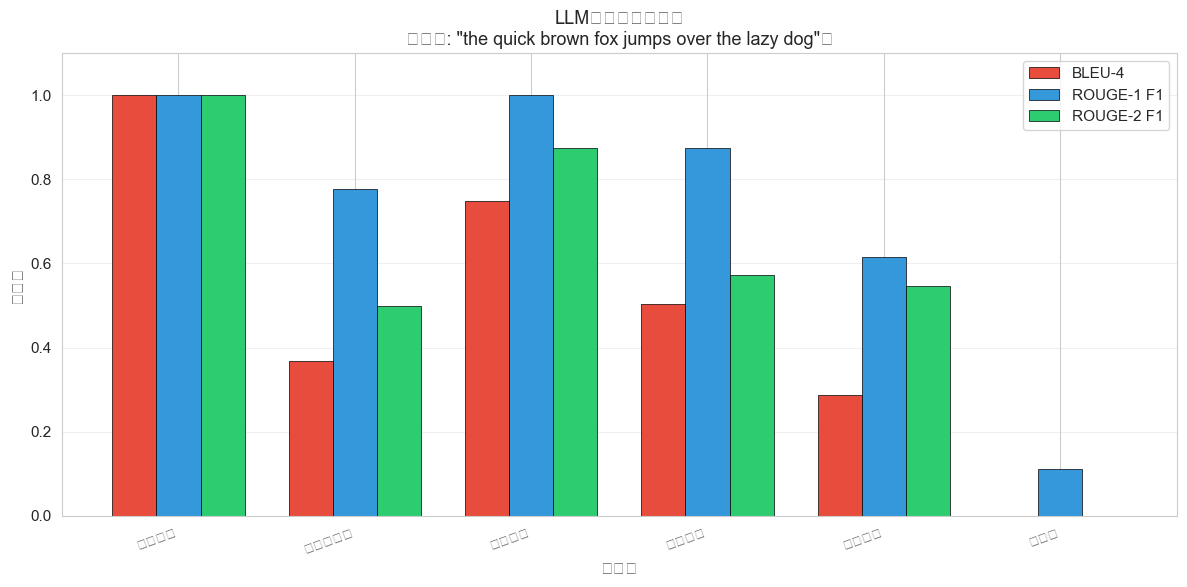

【評価指標の使い分け】
・BLEU: 翻訳の評価に標準。n-gram精度ベース。短い生成にペナルティ。
・ROUGE: 要約の評価に標準。n-gram再現率ベース。重要語の網羅度。
・パープレキシティ: 言語モデル自体の評価。生成テキストの評価には不向き。

⚠️ いずれも参照文との表面的な一致を測るため、意味的な品質は測れない
   → 人間評価やLLM-as-a-Judge がますます重要に


In [9]:
# ============================================================
# 評価指標の比較可視化
# ============================================================

# 複数の生成例に対して各指標を計算
reference = "the quick brown fox jumps over the lazy dog".split()

hypotheses = {
    '完全一致': "the quick brown fox jumps over the lazy dog".split(),
    '同義語置換': "the fast brown fox leaps over the lazy dog".split(),
    '語順変更': "over the lazy dog the quick brown fox jumps".split(),
    '部分一致': "the brown fox jumps over the dog".split(),
    '短い生成': "the quick brown fox".split(),
    '無関係': "a big red car drives down the road today".split(),
}

# 各指標を計算
results = {}
for name, hyp in hypotheses.items():
    results[name] = {
        'BLEU-4': bleu_score(reference, hyp, max_n=4),
        'ROUGE-1 F1': rouge_n(reference, hyp, n=1)['f1'],
        'ROUGE-2 F1': rouge_n(reference, hyp, n=2)['f1'],
    }

# 可視化
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['BLEU-4', 'ROUGE-1 F1', 'ROUGE-2 F1']
names = list(results.keys())
x = np.arange(len(names))
width = 0.25

colors_metrics = ['#e74c3c', '#3498db', '#2ecc71']

for i, metric in enumerate(metrics):
    values = [results[name][metric] for name in names]
    ax.bar(x + i * width, values, width, label=metric, color=colors_metrics[i],
           edgecolor='black', linewidth=0.5)

ax.set_xlabel('生成文', fontsize=12)
ax.set_ylabel('スコア', fontsize=12)
ax.set_title('LLM評価指標の比較\n（参照: "the quick brown fox jumps over the lazy dog"）', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(names, fontsize=10, rotation=20, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print("【評価指標の使い分け】")
print("・BLEU: 翻訳の評価に標準。n-gram精度ベース。短い生成にペナルティ。")
print("・ROUGE: 要約の評価に標準。n-gram再現率ベース。重要語の網羅度。")
print("・パープレキシティ: 言語モデル自体の評価。生成テキストの評価には不向き。")
print("\n⚠️ いずれも参照文との表面的な一致を測るため、意味的な品質は測れない")
print("   → 人間評価やLLM-as-a-Judge がますます重要に")

### 8.4 主要ベンチマーク一覧

| ベンチマーク | 評価対象 | 形式 | 代表例 |
|------------|---------|------|--------|
| MMLU | 知識・推論 | 多肢選択 | 57科目の問題 |
| HumanEval | コード生成 | 関数実装 | 164の問題 |
| GSM8K | 数学推論 | 文章題 | 8.5K の算数問題 |
| HellaSwag | 常識推論 | 文完成 | 10K の問題 |
| TruthfulQA | 正確性 | 質問応答 | 誤解されやすい質問 |
| MT-Bench | 対話品質 | 多ターン対話 | GPT-4による自動評価 |

💡 **LLM-as-a-Judge**: GPT-4などの強力なLLMを使って生成品質を評価する手法が増加中。

---

## 9. 言語モデリングの全体像

### 160-167 の知識の統合

```
┌────────────────────────────────────────────────────────┐
│                  言語モデリング スタック                    │
├────────────────────────────────────────────────────────┤
│                                                        │
│  [Layer 1: テキスト処理]                                │
│    160: N-gram/確率的LM → 言語の統計的構造              │
│    161: BPE/トークナイゼーション → テキスト→トークン     │
│                                                        │
│  [Layer 2: アーキテクチャ]                               │
│    162: Transformer → Attention + 位置エンコーディング   │
│    166: 現代LLM → RoPE, GQA, SwiGLU, KV-Cache          │
│                                                        │
│  [Layer 3: 学習]                                        │
│    163: BERT事前学習 → MLM/NSP（双方向理解）            │
│    164: GPT事前学習 → CLM（自己回帰生成）               │
│                                                        │
│  [Layer 4: 推論・生成]                                   │
│    165: デコーディング → Greedy/Beam/Top-k/Top-p        │
│                                                        │
│  [Layer 5: 応用]                                        │
│    167: LoRA/RLHF/RAG → 実用化への技術                  │
│                                                        │
└────────────────────────────────────────────────────────┘
```

### 今後の展望

1. **マルチモーダル**: テキスト + 画像 + 音声 + 動画の統合
2. **長コンテキスト**: 100K+ トークンの処理（RoPE外挿、Ring Attention）
3. **エージェント**: ツール使用、計画、自律的タスク実行
4. **効率化**: 蒸留、量子化、推測デコーディング
5. **安全性**: より高度なアライメント、Constitutional AI

---

## 10. まとめ・チートシート・よくある間違い・自己評価クイズ

### 10.1 まとめ

1. **LoRA**: 低ランク行列 ΔW = BA で効率的ファインチューニング（パラメータ99%削減）
2. **QLoRA**: 4bit量子化 + LoRA で消費者向けGPUでのFT実現
3. **Instruction Tuning**: 指示-応答ペアで指示遂行能力を獲得
4. **RLHF/DPO**: 人間の好みに合わせたモデルの最適化
5. **RAG**: 検索（157）+ 生成（167）で知識を外部化
6. **評価指標**: パープレキシティ、BLEU、ROUGE、ベンチマーク

### 10.2 ファインチューニング手法チートシート

| 手法 | パラメータ | メモリ | 性能 | 適用場面 |
|------|----------|--------|------|--------|
| フルFT | 全て | 最大 | 最高 | 十分な計算資源がある場合 |
| LoRA | ~0.1-1% | 中 | ≈フルFT | GPUメモリが限られる場合 |
| QLoRA | ~0.1-1% | 最小 | ≈LoRA | 消費者向けGPU |
| Prompt Tuning | ~0.01% | 最小 | やや劣る | 超軽量な適応 |

### 10.3 評価指標チートシート

| 指標 | 対象 | 方向 | 数式の核心 |
|------|------|------|----------|
| パープレキシティ | LM自体 | 低いほど良い | exp(平均負対数尤度) |
| BLEU | 翻訳/生成 | 高いほど良い | n-gram精度の幾何平均 |
| ROUGE | 要約 | 高いほど良い | n-gram再現率 |
| MMLU | 知識 | 高いほど良い | 多肢選択正答率 |

### 10.4 よくある間違い

#### 間違い 1: LoRAを全ての重み行列に適用すれば良いと思い込む

一般的には、Attention の Q, V 射影のみに適用するだけで十分な場合が多いです（元のLoRA論文でも検証済み）。K, FFN への適用は追加のコストに見合う改善がないことが多いです。ただし、タスクに依存するため実験で確認することが重要です。

#### 間違い 2: BLEUスコアが高い = 良い生成と判断する

BLEUはn-gramの表面的な一致を測るため、意味的に正しくても表現が異なれば低スコアになります。逆に、文法的に不自然でもn-gramが一致すれば高スコアになる場合があります。BLEUは翻訳品質の一指標であり、絶対的な品質指標ではありません。

#### 間違い 3: RAGではどんな質問にも正確に答えられると思い込む

RAGの品質は検索の品質に強く依存します。関連文書が正しく検索されなければ、生成も不正確になります。また、検索された文書に情報がない場合、LLMが「知らない」と正直に答えるかは、アライメント（RLHF等）の品質に依存します。

### 10.5 自己評価クイズ

---

**Q1.** LoRAで rank r=8, d_model=4096 の場合、LoRAパラメータは元の重み行列の何%ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 約0.39%

元の重み: 4096 × 4096 = 16,777,216 パラメータ
LoRA: 2 × 4096 × 8 = 65,536 パラメータ
比率: 65,536 / 16,777,216 ≈ 0.0039 = 0.39%

</details>

---

**Q2.** RLHFにおけるKL制約の役割は何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 最適化されるモデルが元のSFTモデルから離れすぎないようにする制約。

KL制約がないと、モデルは報酬モデルの弱点を「ハック」して高い報酬を得るが実際には低品質な出力を生成する「reward hacking」が起こります。KL制約により、元のモデルの言語能力を維持しながら、人間の好みに沿った改善を行えます。

</details>

---

**Q3.** BLEUとROUGEの主な違いは何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: BLEUは**精度（Precision）**ベース、ROUGEは**再現率（Recall）**ベース。

- BLEU: 生成文中のn-gramが参照文にどれだけ含まれるか → 翻訳向き
- ROUGE: 参照文中のn-gramが生成文にどれだけ含まれるか → 要約向き

要約では参照文の重要な内容を網羅することが大切（再現率）、翻訳では余分な情報を生成しないことが大切（精度）。

</details>

---

**Q4.** DPOがRLHFより実装がシンプルな理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: DPOは報酬モデルとRL最適化（PPO）を不要にし、好みデータから直接教師あり学習として方策を最適化するため。

RLHFでは：報酬モデルの学習 → PPOの安定した実装（ε-clipping, GAE等）が必要。
DPOでは：好みペア(y_w, y_l)に対する二値分類的な損失関数のみ → 通常の教師あり学習として実装可能。

</details>

---

**Q5.** RAGで検索品質が低い場合、どのような問題が生じますか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 「ゴミを入れればゴミが出る（Garbage In, Garbage Out）」問題。

無関連な文書が検索されると、LLMはその文書に基づいて回答するため、不正確な情報を自信を持って生成します（hallucination）。対策としては：検索の再ランキング、フィルタリング閾値の設定、マルチクエリ検索、クロスエンコーダによるリランキング等があります。

</details>

---

### シリーズ完結

おめでとうございます！言語モデリングシリーズ（160-167）を完了しました。

このシリーズでは以下を学びました：
- N-gramからTransformerまでの言語モデルの進化
- BERT（双方向理解）とGPT（自己回帰生成）の両方の事前学習
- 多様なデコーディング戦略と現代LLMの効率化技術
- ファインチューニング、アライメント、RAG、評価指標

これらの知識は、現代のAIシステムを理解し活用するための強固な基盤となります。

---

## 参考文献

1. Hu, E. J., et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv:2106.09685.
2. Dettmers, T., et al. (2023). *QLoRA: Efficient Finetuning of Quantized Language Models*. NeurIPS 2023.
3. Wei, J., et al. (2021). *Finetuned Language Models Are Zero-Shot Learners*. arXiv:2109.01652.
4. Ouyang, L., et al. (2022). *Training language models to follow instructions with human feedback*. NeurIPS 2022.
5. Rafailov, R., et al. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model*. NeurIPS 2023.
6. Lewis, P., et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS 2020.
7. Papineni, K., et al. (2002). *BLEU: a Method for Automatic Evaluation of Machine Translation*. ACL 2002.
8. Lin, C.-Y. (2004). *ROUGE: A Package for Automatic Evaluation of Summaries*. ACL Workshop.